# Transfer Learning Using MobileNetV2

This notebook implements an improved steel surface defect classification model using transfer learning. A pretrained MobileNetV2 model will be adapted and trained using the prepared NEU surface defect dataset.

In [36]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU available: True
GPU name: Tesla T4


Import the required libraries

In [39]:
import os
import copy
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


Set a random seed

In [40]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print("Random seed set to:", RANDOM_SEED)

Random seed set to: 42


Define the computing device

In [41]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device being used:", device)

Device being used: cuda


Locate the shared project folder

In [42]:
MY_DRIVE = Path("/content/drive/MyDrive")

print("Folders inside My Drive:")

for item in MY_DRIVE.iterdir():
    if item.is_dir():
        print(item.name)

Folders inside My Drive:
Colab Notebooks
e23-co5430-Surface-Defect-Detection
split


Define the project path

In [43]:
PROJECT_DIR = Path(
    "/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection"
)

print("Project path:", PROJECT_DIR)
print("Project folder exists:", PROJECT_DIR.exists())

Project path: /content/drive/MyDrive/e23-co5430-Surface-Defect-Detection
Project folder exists: True


Inspect the project structure

In [44]:
for root, directories, files in os.walk(PROJECT_DIR):
    level = str(root).replace(str(PROJECT_DIR), "").count(os.sep)

    if level > 3:
        continue

    indent = "    " * level
    print(f"{indent}{Path(root).name}/")

    for file_name in files[:5]:
        print(f"{indent}    {file_name}")

e23-co5430-Surface-Defect-Detection/
    README.md
    notebooks/
        03_mobilenetv2.ipynb
        01_dataset_preparation.ipynb
        02_baseline_cnn.ipynb
        04_resnet18.ipynb
    results/
        dataset_split_summary.csv
        dataset_split.csv
        train_files.csv
        validation_files.csv
        test_files.csv
        baseline/
            training_loss_curve.png
            training_accuracy_curve.png
            confusion_matrix.png
            metrics.csv
            failure_cases.png
        mobilenetv2/
            mobilenetv2_loss_curve.png
            mobilenetv2_accuracy_curve.png
            mobilenetv2_classification_report.txt
            mobilenetv2_metrics.csv
            mobilenetv2_confusion_matrix.png
        comparison/
            model_comparison_preliminary.csv
    models/
        mobilenetv2_transfer_learning.pth
        baseline_cnn.pth
    report/
    dataset/
        raw/
            crazing/
                crazing_107.jpg
             

Define the dataset paths

In [45]:
TRAIN_DIR = PROJECT_DIR / "dataset" / "split" / "train"
VALIDATION_DIR = PROJECT_DIR / "dataset" / "split" / "validation"
TEST_DIR = PROJECT_DIR / "dataset" / "split" / "test"

MODELS_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results" / "mobilenetv2"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Training path:", TRAIN_DIR)
print("Validation path:", VALIDATION_DIR)
print("Test path:", TEST_DIR)
print("Results path:", RESULTS_DIR)

Training path: /content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/dataset/split/train
Validation path: /content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/dataset/split/validation
Test path: /content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/dataset/split/test
Results path: /content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/results/mobilenetv2


Verify all paths

In [46]:
print("Training folder exists:", TRAIN_DIR.exists())
print("Validation folder exists:", VALIDATION_DIR.exists())
print("Test folder exists:", TEST_DIR.exists())

assert TRAIN_DIR.exists(), "Training split not found. Run 01_dataset_preparation.ipynb first."
assert VALIDATION_DIR.exists(), "Validation split not found. Run 01_dataset_preparation.ipynb first."
assert TEST_DIR.exists(), "Test split not found. Run 01_dataset_preparation.ipynb first."

print("\nUsing fixed dataset split from 01_dataset_preparation.ipynb")

Training folder exists: True
Validation folder exists: True
Test folder exists: True

Using fixed dataset split from 01_dataset_preparation.ipynb


Display the class folders

In [47]:
def show_folder_contents(folder_path):
    print(f"\nContents of: {folder_path}")

    if not folder_path.exists():
        print("Folder does not exist.")
        return

    items = list(folder_path.iterdir())

    if len(items) == 0:
        print("Folder is empty.")
        return

    for item in sorted(items):
        print(item.name)


show_folder_contents(TRAIN_DIR)
show_folder_contents(VALIDATION_DIR)
show_folder_contents(TEST_DIR)


Contents of: /content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/dataset/split/train
crazing
inclusion
patches
pitted_surface
rolled_in_scale
scratches

Contents of: /content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/dataset/split/validation
crazing
inclusion
patches
pitted_surface
rolled_in_scale
scratches

Contents of: /content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/dataset/split/test
crazing
inclusion
patches
pitted_surface
rolled_in_scale
scratches


Define Image Counting Function

In [48]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

def count_images_by_class(directory):
    counts = {}

    for class_folder in sorted(directory.iterdir()):
        if class_folder.is_dir():
            count = sum(
                1
                for file in class_folder.iterdir()
                if file.suffix.lower() in IMAGE_EXTENSIONS
            )
            counts[class_folder.name] = count

    return counts

Recheck the split folders

In [49]:
train_counts = count_images_by_class(TRAIN_DIR)
validation_counts = count_images_by_class(VALIDATION_DIR)
test_counts = count_images_by_class(TEST_DIR)

print("Training counts:", train_counts)
print("Validation counts:", validation_counts)
print("Test counts:", test_counts)

print("\nTotal training images:", sum(train_counts.values()))
print("Total validation images:", sum(validation_counts.values()))
print("Total test images:", sum(test_counts.values()))

Training counts: {'crazing': 210, 'inclusion': 210, 'patches': 210, 'pitted_surface': 210, 'rolled_in_scale': 210, 'scratches': 210}
Validation counts: {'crazing': 45, 'inclusion': 45, 'patches': 45, 'pitted_surface': 45, 'rolled_in_scale': 45, 'scratches': 45}
Test counts: {'crazing': 45, 'inclusion': 45, 'patches': 45, 'pitted_surface': 45, 'rolled_in_scale': 45, 'scratches': 45}

Total training images: 1260
Total validation images: 270
Total test images: 270


Check there is no overlap

In [50]:
for class_name in train_counts.keys():

    train_files = {
        file.name
        for file in (TRAIN_DIR / class_name).iterdir()
    }

    validation_files = {
        file.name
        for file in (VALIDATION_DIR / class_name).iterdir()
    }

    test_files = {
        file.name
        for file in (TEST_DIR / class_name).iterdir()
    }

    assert train_files.isdisjoint(validation_files)
    assert train_files.isdisjoint(test_files)
    assert validation_files.isdisjoint(test_files)

print("No duplicate images were found between the splits.")

No duplicate images were found between the splits.


Verify Test-Set Signature

In [51]:
import hashlib

test_files_for_signature = sorted([
    str(Path(path).relative_to(PROJECT_DIR))
    for path, _ in datasets.ImageFolder(
        root=TEST_DIR
    ).samples
])

test_signature = hashlib.sha256(
    "\n".join(test_files_for_signature).encode()
).hexdigest()

print("Number of test files:", len(test_files_for_signature))
print("Test-set signature:", test_signature)

Number of test files: 270
Test-set signature: 5eb766167cea0edfc0662ea754c9938bd645ed30b3cf33ff614e9c28a8770213


## Image Preprocessing and Data Augmentation

Training images are resized, augmented, converted to three channels, and normalized. Validation and test images are only resized and normalized.

In [52]:
IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),

    # Convert grayscale images into 3 channels for MobileNetV2
    transforms.Grayscale(num_output_channels=3),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

evaluation_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Image transformations created successfully.")

Image transformations created successfully.


Load the datasets

In [53]:
train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

validation_dataset = datasets.ImageFolder(
    root=VALIDATION_DIR,
    transform=evaluation_transform
)

test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=evaluation_transform
)

print("Training images:", len(train_dataset))
print("Validation images:", len(validation_dataset))
print("Test images:", len(test_dataset))

print("\nClasses:", train_dataset.classes)
print("Class mapping:", train_dataset.class_to_idx)

Training images: 1260
Validation images: 270
Test images: 270

Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled_in_scale', 'scratches']
Class mapping: {'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled_in_scale': 4, 'scratches': 5}


Verify class order

In [54]:
assert train_dataset.classes == validation_dataset.classes
assert train_dataset.classes == test_dataset.classes

CLASS_NAMES = train_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

print("All dataset splits use the same class order.")
print("Number of classes:", NUM_CLASSES)
print("Class names:", CLASS_NAMES)

All dataset splits use the same class order.
Number of classes: 6
Class names: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled_in_scale', 'scratches']


Create DataLoaders

In [56]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))

Training batches: 40
Validation batches: 9
Test batches: 9


Check one batch

In [57]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 10 labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
First 10 labels: tensor([2, 4, 0, 0, 1, 4, 4, 3, 2, 4])


Display sample images

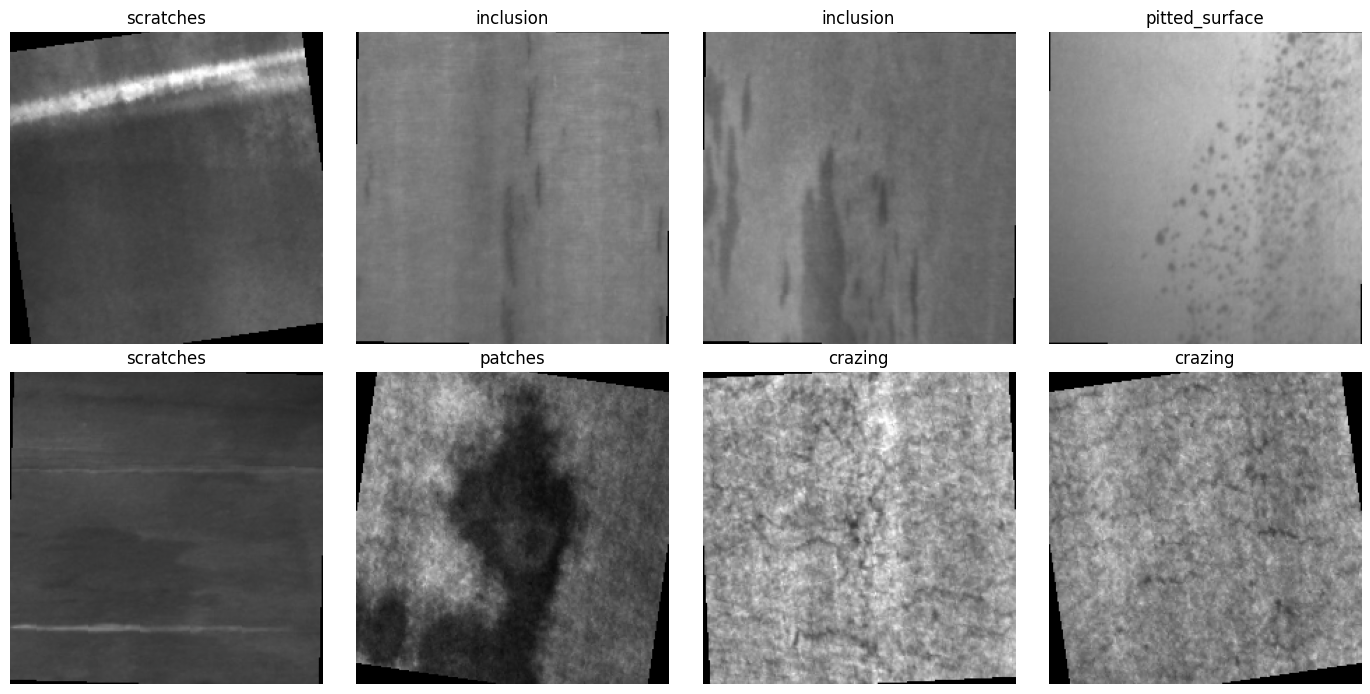

In [58]:
def denormalize_image(image_tensor):
    image = image_tensor.cpu().numpy().transpose((1, 2, 0))

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image = std * image + mean
    image = np.clip(image, 0, 1)

    return image


images, labels = next(iter(train_loader))

plt.figure(figsize=(14, 7))

for index in range(8):
    plt.subplot(2, 4, index + 1)

    image = denormalize_image(images[index])
    plt.imshow(image)

    class_name = CLASS_NAMES[labels[index].item()]
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Load Pretrained MobileNetV2

A pretrained MobileNetV2 model is loaded. The pretrained weights contain features learned from the ImageNet dataset, allowing faster and more accurate learning compared to training a CNN from scratch.

In [59]:
# Load pretrained MobileNetV2
weights = models.MobileNet_V2_Weights.DEFAULT

model = models.mobilenet_v2(weights=weights)

print("MobileNetV2 loaded successfully!")

MobileNetV2 loaded successfully!


In [60]:
print(model)

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

Freeze the feature extractor

In [61]:
for parameter in model.features.parameters():
    parameter.requires_grad = False

print("Feature extraction layers frozen.")

Feature extraction layers frozen.


Replace the last layer

In [62]:
input_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(
    input_features,
    NUM_CLASSES
)

model = model.to(device)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=6, bias=True)
)


Verify the replacement

In [27]:
print("Number of classes:", NUM_CLASSES)
print("Output neurons:", model.classifier[1].out_features)

Number of classes: 6
Output neurons: 6


Count trainable parameters

In [63]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters      : {total_params:,}")
print(f"Trainable parameters  : {trainable_params:,}")

Total parameters      : 2,231,558
Trainable parameters  : 7,686


## Loss Function and Optimizer

CrossEntropyLoss is used for multi-class classification. The Adam optimizer updates only the trainable classifier parameters while the pretrained feature extractor remains frozen.

In [64]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer (only updates the classifier)
optimizer = optim.Adam(
    model.classifier.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## Training Function

This function trains the MobileNetV2 model for one epoch and returns the average training loss and accuracy.

In [65]:
def train_one_epoch(model, dataloader, criterion, optimizer):
## model → MobileNetV2
## dataloader → Training images
## criterion → CrossEntropyLoss
## optimizer → Adam

    # Set model to training mode
    model.train()

    # Initialize variables
    running_loss = 0.0
    correct_predictions = 0
    total_images = 0

    # Loop through all training batches
    for images, labels in dataloader:

        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update model weights
        optimizer.step()

        # Add batch loss
        running_loss += loss.item()

        # Get predicted class
        _, predicted = torch.max(outputs, 1)

        # Count correct predictions
        total_images += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    # Calculate average loss and accuracy
    epoch_loss = running_loss / len(dataloader)
    epoch_accuracy = correct_predictions / total_images

    return epoch_loss, epoch_accuracy

## Validation Function

This function evaluates the model using the validation dataset. Model weights are not updated during validation.

In [66]:
def validate_model(model, dataloader, criterion):

    # Set model to evaluation mode
    model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_images = 0

    # Disable gradient calculation
    with torch.no_grad():

        for images, labels in dataloader:

            # Move data to GPU
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Add batch loss
            running_loss += loss.item()

            # Get predicted class
            _, predicted = torch.max(outputs, 1)

            # Count correct predictions
            total_images += labels.size(0)
            correct_predictions += (
                predicted == labels
            ).sum().item()

    # Calculate average loss and accuracy
    epoch_loss = running_loss / len(dataloader)
    epoch_accuracy = correct_predictions / total_images

    return epoch_loss, epoch_accuracy

## Model Training

The model is trained for multiple epochs. After every epoch, training and validation performance are recorded. The best model is saved using validation accuracy.

In [67]:
EPOCHS = 10

train_losses = []
validation_losses = []

train_accuracies = []
validation_accuracies = []

print("Training settings created.")
print("Epochs:", EPOCHS)

best_validation_accuracy = 0.0
best_model_weights = copy.deepcopy(model.state_dict())

start_time = time.time()

for epoch in range(EPOCHS):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    validation_loss, validation_accuracy = validate_model(
        model,
        validation_loader,
        criterion
    )

    train_losses.append(train_loss)
    validation_losses.append(validation_loss)

    train_accuracies.append(train_accuracy)
    validation_accuracies.append(validation_accuracy)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy * 100:.2f}% | "
        f"Validation Loss: {validation_loss:.4f} | "
        f"Validation Accuracy: {validation_accuracy * 100:.2f}%"
    )

    # Save the best model weights
    if validation_accuracy > best_validation_accuracy:

        best_validation_accuracy = validation_accuracy
        best_model_weights = copy.deepcopy(
            model.state_dict()
        )

training_time = time.time() - start_time

# Restore the best model
model.load_state_dict(best_model_weights)

print("\nTraining completed.")
print(
    f"Best validation accuracy: "
    f"{best_validation_accuracy * 100:.2f}%"
)
print(
    f"Total training time: "
    f"{training_time / 60:.2f} minutes"
)

Training settings created.
Epochs: 10
Epoch 1/10 | Train Loss: 1.0139 | Train Accuracy: 77.70% | Validation Loss: 0.7518 | Validation Accuracy: 92.96%
Epoch 2/10 | Train Loss: 0.3730 | Train Accuracy: 95.63% | Validation Loss: 0.2543 | Validation Accuracy: 98.89%
Epoch 3/10 | Train Loss: 0.2346 | Train Accuracy: 96.59% | Validation Loss: 0.1715 | Validation Accuracy: 98.52%
Epoch 4/10 | Train Loss: 0.1893 | Train Accuracy: 97.62% | Validation Loss: 0.1366 | Validation Accuracy: 98.89%
Epoch 5/10 | Train Loss: 0.1379 | Train Accuracy: 97.70% | Validation Loss: 0.1151 | Validation Accuracy: 98.89%
Epoch 6/10 | Train Loss: 0.1462 | Train Accuracy: 97.46% | Validation Loss: 0.0922 | Validation Accuracy: 98.89%
Epoch 7/10 | Train Loss: 0.1244 | Train Accuracy: 97.46% | Validation Loss: 0.0735 | Validation Accuracy: 99.63%
Epoch 8/10 | Train Loss: 0.1106 | Train Accuracy: 97.70% | Validation Loss: 0.0696 | Validation Accuracy: 98.89%
Epoch 9/10 | Train Loss: 0.1045 | Train Accuracy: 97.54% |

Save the best model

In [68]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODELS_DIR / "mobilenetv2_frozen.pth"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_names": CLASS_NAMES,
        "num_classes": NUM_CLASSES,
        "image_size": IMAGE_SIZE,
        "best_validation_accuracy": best_validation_accuracy
    },
    MODEL_PATH
)

print("Frozen MobileNetV2 model saved to:")
print(MODEL_PATH)

Frozen MobileNetV2 model saved to:
/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/models/mobilenetv2_frozen.pth


Plot loss curves

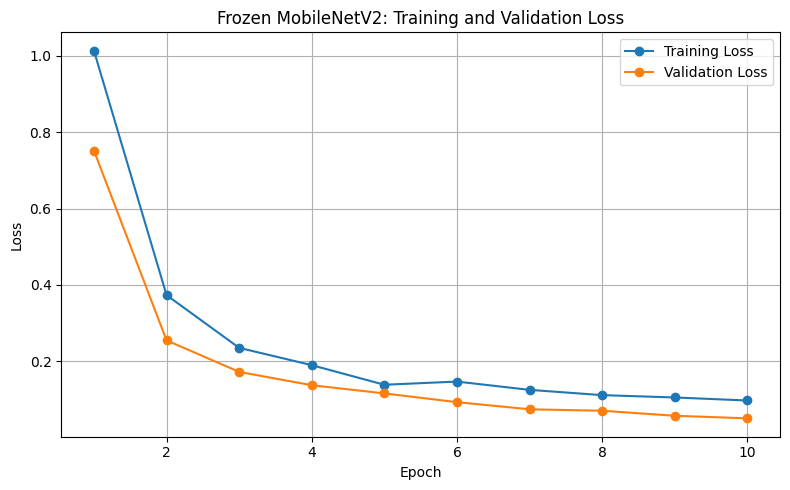

Loss graph saved to:
/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/results/mobilenetv2/frozen_training_loss.png


In [69]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_range,
    validation_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Frozen MobileNetV2: Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_graph_path = (
    RESULTS_DIR / "frozen_training_loss.png"
)

plt.savefig(loss_graph_path, dpi=300)
plt.show()

print("Loss graph saved to:")
print(loss_graph_path)

Plot accuracy curves

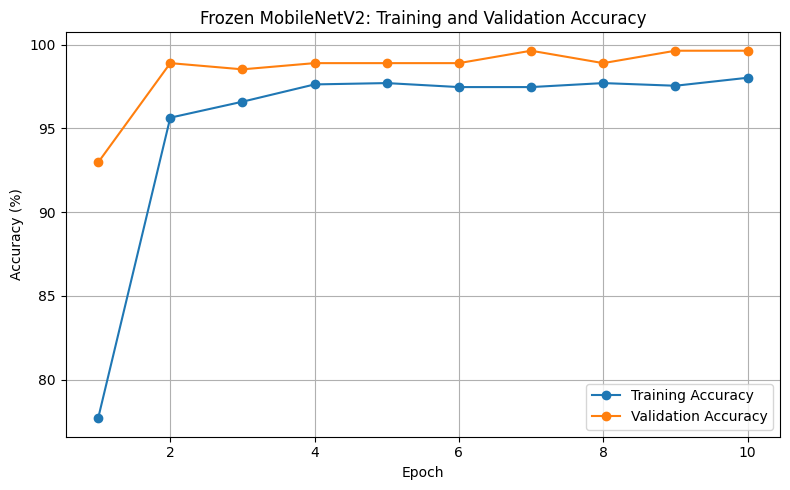

Accuracy graph saved to:
/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/results/mobilenetv2/frozen_training_accuracy.png


In [70]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    [accuracy * 100 for accuracy in train_accuracies],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    [
        accuracy * 100
        for accuracy in validation_accuracies
    ],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Frozen MobileNetV2: Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

accuracy_graph_path = (
    RESULTS_DIR / "frozen_training_accuracy.png"
)

plt.savefig(accuracy_graph_path, dpi=300)
plt.show()

print("Accuracy graph saved to:")
print(accuracy_graph_path)

## Test Set Evaluation

The best-performing MobileNetV2 model is evaluated using the untouched test dataset.

In [71]:
def evaluate_test_set(model, dataloader):

    # Set model to evaluation mode
    model.eval()

    all_labels = []
    all_predictions = []
    all_confidences = []

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            # Get model outputs
            outputs = model(images)

            # Convert outputs into probabilities
            probabilities = torch.softmax(outputs, dim=1)

            # Get confidence and predicted class
            confidence, predicted = torch.max(
                probabilities,
                dim=1
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predicted.cpu().numpy()
            )

            all_confidences.extend(
                confidence.cpu().numpy()
            )

    return (
        np.array(all_labels),
        np.array(all_predictions),
        np.array(all_confidences)
    )

In [72]:
true_labels, predicted_labels, confidence_scores = (
    evaluate_test_set(model, test_loader)
)

print("Number of test predictions:", len(predicted_labels))

Number of test predictions: 270


Calculate evaluation metrics

In [73]:
test_accuracy = accuracy_score(
    true_labels,
    predicted_labels
)

test_precision = precision_score(
    true_labels,
    predicted_labels,
    average="macro",
    zero_division=0
)

test_recall = recall_score(
    true_labels,
    predicted_labels,
    average="macro",
    zero_division=0
)

test_f1 = f1_score(
    true_labels,
    predicted_labels,
    average="macro",
    zero_division=0
)

print(f"Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"Macro Precision: {test_precision * 100:.2f}%")
print(f"Macro Recall   : {test_recall * 100:.2f}%")
print(f"Macro F1-Score : {test_f1 * 100:.2f}%")

Test Accuracy : 99.63%
Macro Precision: 99.64%
Macro Recall   : 99.63%
Macro F1-Score : 99.63%


Generate the classification report

In [74]:
report = classification_report(
    true_labels,
    predicted_labels,
    target_names=CLASS_NAMES,
    zero_division=0
)

print(report)

report_path = RESULTS_DIR / "frozen_classification_report.txt"

with open(report_path, "w") as file:
    file.write(report)

print("Classification report saved to:")
print(report_path)

                 precision    recall  f1-score   support

        crazing       1.00      1.00      1.00        45
      inclusion       0.98      1.00      0.99        45
        patches       1.00      1.00      1.00        45
 pitted_surface       1.00      1.00      1.00        45
rolled_in_scale       1.00      1.00      1.00        45
      scratches       1.00      0.98      0.99        45

       accuracy                           1.00       270
      macro avg       1.00      1.00      1.00       270
   weighted avg       1.00      1.00      1.00       270

Classification report saved to:
/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/results/mobilenetv2/frozen_classification_report.txt


Save the overall metrics

In [75]:
metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-Score",
        "Best Validation Accuracy"
    ],
    "Value": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        best_validation_accuracy
    ]
})

metrics_path = RESULTS_DIR / "frozen_metrics.csv"

metrics_df.to_csv(metrics_path, index=False)

display(metrics_df)

print("Metrics saved to:")
print(metrics_path)

,Metric,Value
0,Accuracy,0.996296
1,Macro Precision,0.996377
2,Macro Recall,0.996296
3,Macro F1-Score,0.996296
4,Best Validation Accuracy,0.996296


Metrics saved to:
/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/results/mobilenetv2/frozen_metrics.csv


Create the confusion matrix

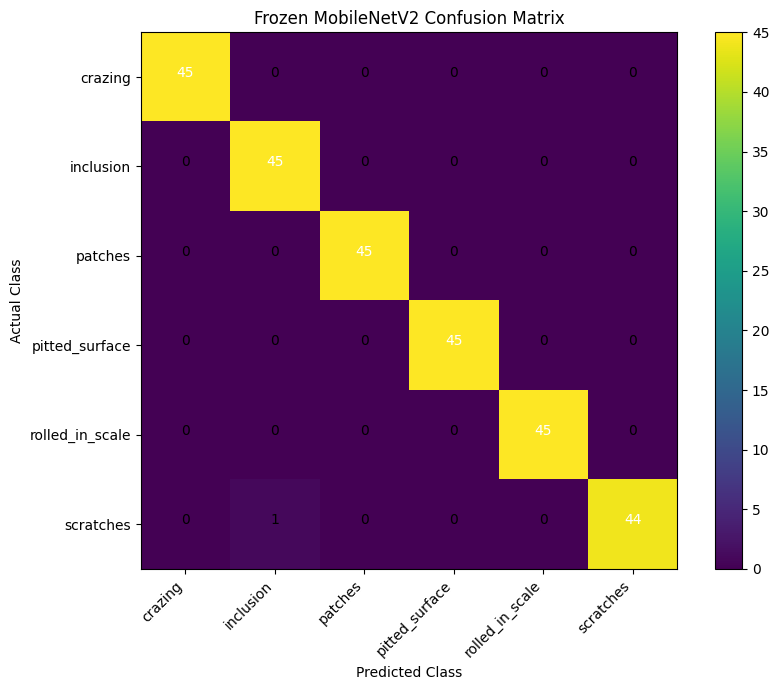

Confusion matrix saved to:
/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/results/mobilenetv2/frozen_confusion_matrix.png


In [76]:
confusion = confusion_matrix(
    true_labels,
    predicted_labels
)

plt.figure(figsize=(9, 7))

plt.imshow(confusion, interpolation="nearest")
plt.title("Frozen MobileNetV2 Confusion Matrix")
plt.colorbar()

tick_positions = np.arange(len(CLASS_NAMES))

plt.xticks(
    tick_positions,
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

plt.yticks(
    tick_positions,
    CLASS_NAMES
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

threshold = confusion.max() / 2

for row in range(confusion.shape[0]):
    for column in range(confusion.shape[1]):

        plt.text(
            column,
            row,
            str(confusion[row, column]),
            horizontalalignment="center",
            color=(
                "white"
                if confusion[row, column] > threshold
                else "black"
            )
        )

plt.tight_layout()

confusion_path = (
    RESULTS_DIR / "frozen_confusion_matrix.png"
)

plt.savefig(
    confusion_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved to:")
print(confusion_path)

Display qualitative results

In [97]:
def show_predictions(
    model,
    dataset,
    class_names,
    number_of_images=8,
    save_name="qualitative_results.png"
):

    model.eval()

    selected_indices = random.sample(
        range(len(dataset)),
        number_of_images
    )

    plt.figure(figsize=(14, 8))

    with torch.no_grad():

        for position, dataset_index in enumerate(
            selected_indices
        ):

            image, actual_label = dataset[dataset_index]

            input_image = image.unsqueeze(0).to(device)

            output = model(input_image)

            probabilities = torch.softmax(
                output,
                dim=1
            )

            confidence, predicted_label = torch.max(
                probabilities,
                dim=1
            )

            displayed_image = denormalize_image(image)

            plt.subplot(
                2,
                4,
                position + 1
            )

            plt.imshow(displayed_image)

            actual_name = class_names[
                actual_label
            ]

            predicted_name = class_names[
                predicted_label.item()
            ]

            confidence_percentage = (
                confidence.item() * 100
            )

            plt.title(
                f"Actual: {actual_name}\n"
                f"Predicted: {predicted_name}\n"
                f"Confidence: {confidence_percentage:.1f}%"
            )

            plt.axis("off")

    plt.tight_layout()

    qualitative_path = (
        RESULTS_DIR / save_name
    )

    plt.savefig(
        qualitative_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Qualitative results saved to:")
    print(qualitative_path)

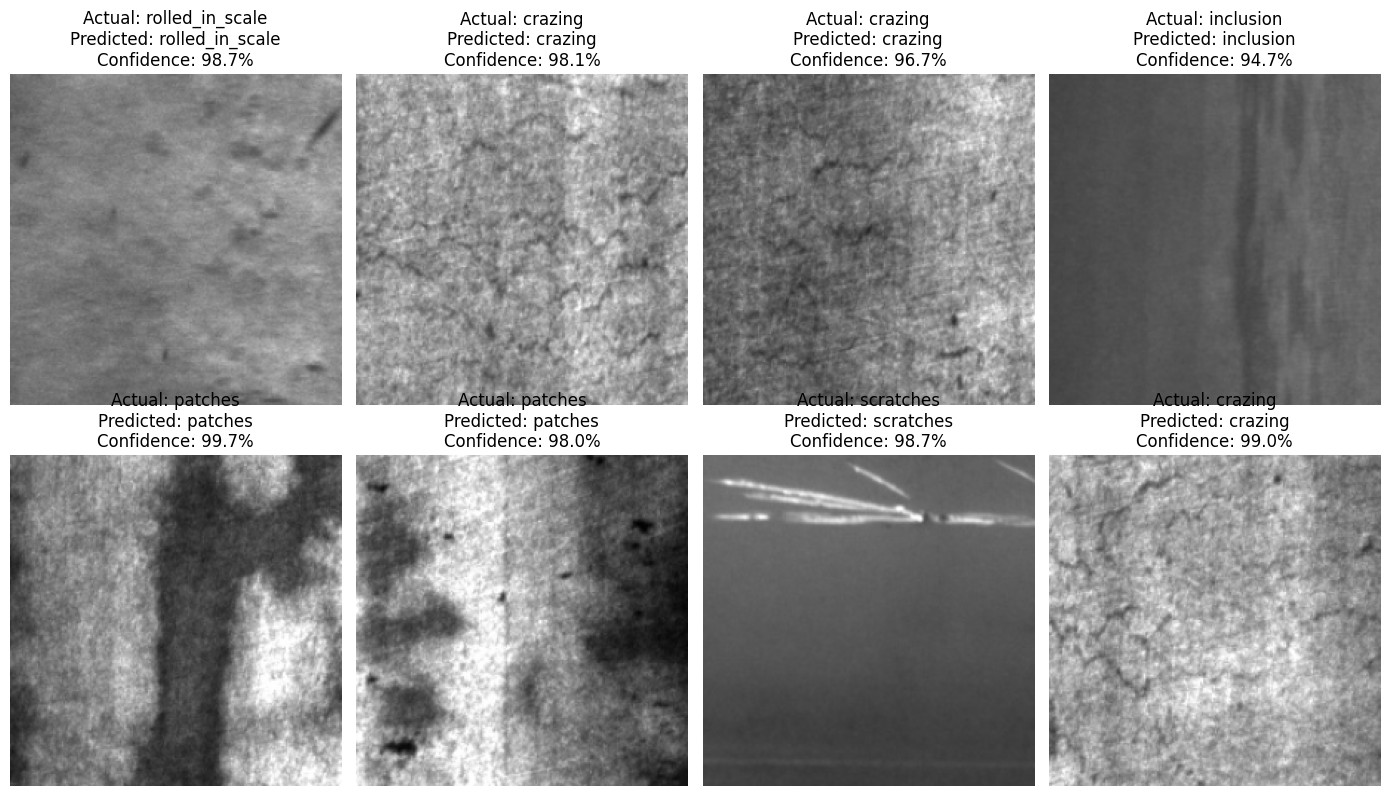

Qualitative results saved to:
/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/results/mobilenetv2/frozen_qualitative_results.png


In [98]:
show_predictions(
    model,
    test_dataset,
    CLASS_NAMES,
    number_of_images=8,
    save_name="frozen_qualitative_results.png"
)

Find failure cases

In [79]:
incorrect_indices = np.where(
    true_labels != predicted_labels
)[0]

print("Total incorrect predictions:", len(incorrect_indices))
print(
    f"Error rate: "
    f"{len(incorrect_indices) / len(true_labels) * 100:.2f}%"
)

Total incorrect predictions: 1
Error rate: 0.37%


In [80]:
def show_failure_cases(
    dataset,
    true_labels,
    predicted_labels,
    confidence_scores,
    class_names,
    maximum_images=8
):

    incorrect_indices = np.where(
        true_labels != predicted_labels
    )[0]

    if len(incorrect_indices) == 0:
        print("No incorrect predictions were found.")
        return

    number_to_show = min(
        maximum_images,
        len(incorrect_indices)
    )

    selected_indices = incorrect_indices[:number_to_show]

    plt.figure(figsize=(14, 8))

    for position, dataset_index in enumerate(
        selected_indices
    ):

        image, _ = dataset[dataset_index]

        displayed_image = denormalize_image(image)

        actual_name = class_names[
            true_labels[dataset_index]
        ]

        predicted_name = class_names[
            predicted_labels[dataset_index]
        ]

        confidence = (
            confidence_scores[dataset_index] * 100
        )

        plt.subplot(2, 4, position + 1)
        plt.imshow(displayed_image)

        plt.title(
            f"Actual: {actual_name}\n"
            f"Predicted: {predicted_name}\n"
            f"Confidence: {confidence:.1f}%"
        )

        plt.axis("off")

    plt.tight_layout()

    failure_path = (
      RESULTS_DIR / "frozen_failure_cases.png"
  )

    plt.savefig(
        failure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Failure cases saved to:")
    print(failure_path)


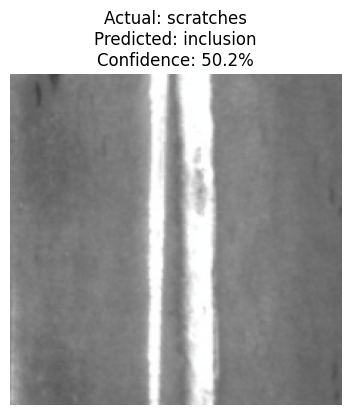

Failure cases saved to:
/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/results/mobilenetv2/frozen_failure_cases.png


In [81]:
    show_failure_cases(
    test_dataset,
    true_labels,
    predicted_labels,
    confidence_scores,
    CLASS_NAMES
)

Save all individual predictions

In [82]:
predictions_df = pd.DataFrame({
    "Actual Class": [
        CLASS_NAMES[label]
        for label in true_labels
    ],
    "Predicted Class": [
        CLASS_NAMES[label]
        for label in predicted_labels
    ],
    "Confidence": confidence_scores,
    "Correct": true_labels == predicted_labels
})

predictions_path = (
    RESULTS_DIR / "frozen_test_predictions.csv"
)

predictions_df.to_csv(
    predictions_path,
    index=False
)

display(predictions_df.head())

print("Predictions saved to:")
print(predictions_path)

,Actual Class,Predicted Class,Confidence,Correct
0,crazing,crazing,0.889041,True
1,crazing,crazing,0.929429,True
2,crazing,crazing,0.943787,True
3,crazing,crazing,0.979456,True
4,crazing,crazing,0.870251,True


Predictions saved to:
/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/results/mobilenetv2/frozen_test_predictions.csv


## Observations

- Training and validation accuracy improved during training.
- The validation accuracy remained close to the training accuracy, indicating limited overfitting.
- Some defect classes were easier to identify than others.
- Most incorrect predictions occurred between visually similar surface textures.
- Some wrong predictions had high confidence, showing that further fine-tuning is required.

## MobileNetV2 Results

The MobileNetV2 transfer-learning model was evaluated on the common test set.

### Test Performance
- Accuracy: 99.63%
- Macro Precision: 99.64%
- Macro Recall: 99.63%
- Macro F1-Score: 99.63%

Out of 270 test images, 269 were classified correctly.

The only observed error was a `scratches` image classified as `inclusion`.

The results indicate that transfer learning provides a substantial improvement over the custom CNN baseline.

## Fine-Tuning MobileNetV2

Reload the best frozen MobileNetV2 model

In [84]:
finetuned_model = models.mobilenet_v2(
    weights=models.MobileNet_V2_Weights.DEFAULT
)

input_features = finetuned_model.classifier[1].in_features

finetuned_model.classifier[1] = nn.Linear(
    input_features,
    NUM_CLASSES
)

checkpoint = torch.load(
    MODELS_DIR / "mobilenetv2_frozen.pth",
    map_location=device
)

finetuned_model.load_state_dict(
    checkpoint["model_state_dict"]
)

finetuned_model = finetuned_model.to(device)

print("Frozen MobileNetV2 checkpoint loaded.")

Frozen MobileNetV2 checkpoint loaded.


In [85]:
# Freeze all feature layers first
for parameter in finetuned_model.features.parameters():
    parameter.requires_grad = False

# Unfreeze only the last 3 feature blocks
for parameter in finetuned_model.features[-3:].parameters():
    parameter.requires_grad = True

# Classifier remains trainable
for parameter in finetuned_model.classifier.parameters():
    parameter.requires_grad = True

trainable_parameters = sum(
    p.numel()
    for p in finetuned_model.parameters()
    if p.requires_grad
)

print("Trainable parameters:", trainable_parameters)

Trainable parameters: 1213766


In [86]:
finetune_criterion = nn.CrossEntropyLoss()

finetune_optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        finetuned_model.parameters()
    ),
    lr=0.0001
)

FINETUNE_EPOCHS = 5

print("Fine-tuning epochs:", FINETUNE_EPOCHS)
print("Fine-tuning learning rate: 0.0001")

Fine-tuning epochs: 5
Fine-tuning learning rate: 0.0001


Fine-tuning loop

In [87]:
finetune_train_losses = []
finetune_validation_losses = []

finetune_train_accuracies = []
finetune_validation_accuracies = []

best_finetune_validation_accuracy = 0.0
best_finetune_weights = copy.deepcopy(
    finetuned_model.state_dict()
)

start_time = time.time()

for epoch in range(FINETUNE_EPOCHS):

    train_loss, train_accuracy = train_one_epoch(
        finetuned_model,
        train_loader,
        finetune_criterion,
        finetune_optimizer
    )

    validation_loss, validation_accuracy = validate_model(
        finetuned_model,
        validation_loader,
        finetune_criterion
    )

    finetune_train_losses.append(train_loss)
    finetune_validation_losses.append(validation_loss)

    finetune_train_accuracies.append(train_accuracy)
    finetune_validation_accuracies.append(validation_accuracy)

    print(
        f"Epoch {epoch + 1}/{FINETUNE_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy * 100:.2f}% | "
        f"Validation Loss: {validation_loss:.4f} | "
        f"Validation Accuracy: {validation_accuracy * 100:.2f}%"
    )

    if validation_accuracy > best_finetune_validation_accuracy:
        best_finetune_validation_accuracy = validation_accuracy
        best_finetune_weights = copy.deepcopy(
            finetuned_model.state_dict()
        )

finetuning_time = time.time() - start_time

finetuned_model.load_state_dict(
    best_finetune_weights
)

print("\nFine-tuning completed.")
print(
    f"Best validation accuracy: "
    f"{best_finetune_validation_accuracy * 100:.2f}%"
)
print(
    f"Fine-tuning time: "
    f"{finetuning_time / 60:.2f} minutes"
)

Epoch 1/5 | Train Loss: 0.0733 | Train Accuracy: 98.41% | Validation Loss: 0.0196 | Validation Accuracy: 100.00%
Epoch 2/5 | Train Loss: 0.0336 | Train Accuracy: 99.52% | Validation Loss: 0.0139 | Validation Accuracy: 100.00%
Epoch 3/5 | Train Loss: 0.0392 | Train Accuracy: 98.73% | Validation Loss: 0.0096 | Validation Accuracy: 100.00%
Epoch 4/5 | Train Loss: 0.0295 | Train Accuracy: 99.21% | Validation Loss: 0.0039 | Validation Accuracy: 100.00%
Epoch 5/5 | Train Loss: 0.0202 | Train Accuracy: 99.52% | Validation Loss: 0.0042 | Validation Accuracy: 100.00%

Fine-tuning completed.
Best validation accuracy: 100.00%
Fine-tuning time: 0.61 minutes


## Save Fine-Tuned Model

In [88]:
FINETUNED_MODEL_PATH = (
    MODELS_DIR / "mobilenetv2_finetuned.pth"
)

torch.save(
    {
        "model_state_dict": finetuned_model.state_dict(),
        "class_names": CLASS_NAMES,
        "num_classes": NUM_CLASSES,
        "image_size": IMAGE_SIZE,
        "best_validation_accuracy": best_finetune_validation_accuracy
    },
    FINETUNED_MODEL_PATH
)

print("Fine-tuned MobileNetV2 saved to:")
print(FINETUNED_MODEL_PATH)

Fine-tuned MobileNetV2 saved to:
/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/models/mobilenetv2_finetuned.pth


Fine-Tuning Loss Curve

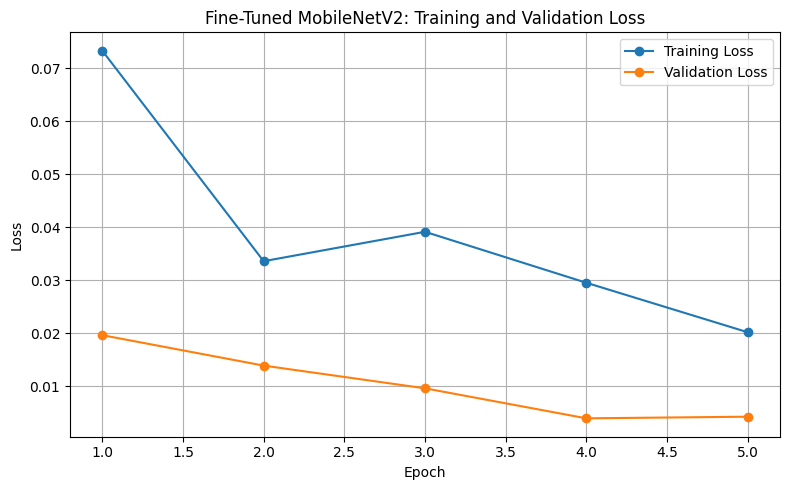

Fine-tuning loss graph saved to:
/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/results/mobilenetv2/finetuned_training_loss.png


In [89]:
finetune_epochs_range = range(
    1,
    FINETUNE_EPOCHS + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    finetune_epochs_range,
    finetune_train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    finetune_epochs_range,
    finetune_validation_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fine-Tuned MobileNetV2: Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

finetune_loss_path = (
    RESULTS_DIR / "finetuned_training_loss.png"
)

plt.savefig(
    finetune_loss_path,
    dpi=300
)

plt.show()

print("Fine-tuning loss graph saved to:")
print(finetune_loss_path)

Fine-Tuning Accuracy Curve

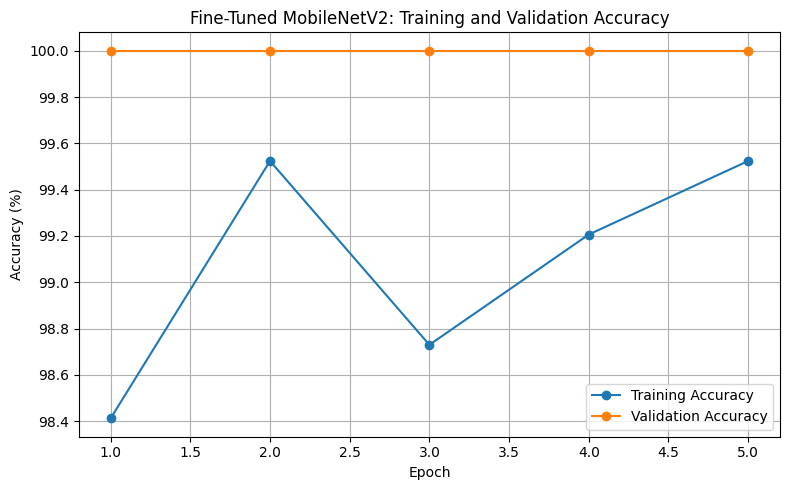

Fine-tuning accuracy graph saved to:
/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/results/mobilenetv2/finetuned_training_accuracy.png


In [90]:
plt.figure(figsize=(8, 5))

plt.plot(
    finetune_epochs_range,
    [
        accuracy * 100
        for accuracy in finetune_train_accuracies
    ],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    finetune_epochs_range,
    [
        accuracy * 100
        for accuracy in finetune_validation_accuracies
    ],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Fine-Tuned MobileNetV2: Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

finetune_accuracy_path = (
    RESULTS_DIR / "finetuned_training_accuracy.png"
)

plt.savefig(
    finetune_accuracy_path,
    dpi=300
)

plt.show()

print("Fine-tuning accuracy graph saved to:")
print(finetune_accuracy_path)

Evaluate Fine-Tuned Model on Test Set

In [91]:
(
    finetuned_true_labels,
    finetuned_predicted_labels,
    finetuned_confidence_scores
) = evaluate_test_set(
    finetuned_model,
    test_loader
)

print(
    "Number of test predictions:",
    len(finetuned_predicted_labels)
)

Number of test predictions: 270


Calculate Fine-Tuned Test Metrics

In [92]:
finetuned_test_accuracy = accuracy_score(
    finetuned_true_labels,
    finetuned_predicted_labels
)

finetuned_test_precision = precision_score(
    finetuned_true_labels,
    finetuned_predicted_labels,
    average="macro",
    zero_division=0
)

finetuned_test_recall = recall_score(
    finetuned_true_labels,
    finetuned_predicted_labels,
    average="macro",
    zero_division=0
)

finetuned_test_f1 = f1_score(
    finetuned_true_labels,
    finetuned_predicted_labels,
    average="macro",
    zero_division=0
)

print(
    f"Fine-Tuned Test Accuracy : "
    f"{finetuned_test_accuracy * 100:.2f}%"
)

print(
    f"Macro Precision: "
    f"{finetuned_test_precision * 100:.2f}%"
)

print(
    f"Macro Recall   : "
    f"{finetuned_test_recall * 100:.2f}%"
)

print(
    f"Macro F1-Score : "
    f"{finetuned_test_f1 * 100:.2f}%"
)

Fine-Tuned Test Accuracy : 100.00%
Macro Precision: 100.00%
Macro Recall   : 100.00%
Macro F1-Score : 100.00%


Fine-Tuned Classification Report

In [93]:
finetuned_report = classification_report(
    finetuned_true_labels,
    finetuned_predicted_labels,
    target_names=CLASS_NAMES,
    zero_division=0
)

print(finetuned_report)

finetuned_report_path = (
    RESULTS_DIR / "finetuned_classification_report.txt"
)

with open(finetuned_report_path, "w") as file:
    file.write(finetuned_report)

print("Fine-tuned classification report saved to:")
print(finetuned_report_path)

                 precision    recall  f1-score   support

        crazing       1.00      1.00      1.00        45
      inclusion       1.00      1.00      1.00        45
        patches       1.00      1.00      1.00        45
 pitted_surface       1.00      1.00      1.00        45
rolled_in_scale       1.00      1.00      1.00        45
      scratches       1.00      1.00      1.00        45

       accuracy                           1.00       270
      macro avg       1.00      1.00      1.00       270
   weighted avg       1.00      1.00      1.00       270

Fine-tuned classification report saved to:
/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/results/mobilenetv2/finetuned_classification_report.txt


Save Fine-Tuned Metrics

In [94]:
finetuned_metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-Score",
        "Best Validation Accuracy"
    ],
    "Value": [
        finetuned_test_accuracy,
        finetuned_test_precision,
        finetuned_test_recall,
        finetuned_test_f1,
        best_finetune_validation_accuracy
    ]
})

finetuned_metrics_path = (
    RESULTS_DIR / "finetuned_metrics.csv"
)

finetuned_metrics_df.to_csv(
    finetuned_metrics_path,
    index=False
)

display(finetuned_metrics_df)

print("Fine-tuned metrics saved to:")
print(finetuned_metrics_path)

,Metric,Value
0,Accuracy,1.0
1,Macro Precision,1.0
2,Macro Recall,1.0
3,Macro F1-Score,1.0
4,Best Validation Accuracy,1.0


Fine-tuned metrics saved to:
/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/results/mobilenetv2/finetuned_metrics.csv


Fine-Tuned Confusion Matrix

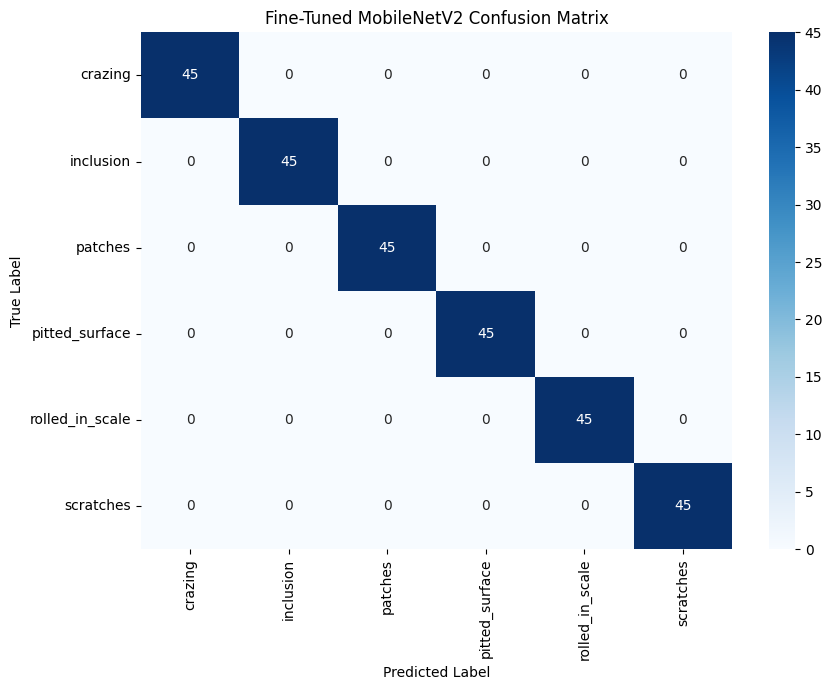

Fine-tuned confusion matrix saved to:
/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/results/mobilenetv2/finetuned_confusion_matrix.png


In [96]:
import seaborn as sns

finetuned_cm = confusion_matrix(
    finetuned_true_labels,
    finetuned_predicted_labels
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    finetuned_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Fine-Tuned MobileNetV2 Confusion Matrix")

plt.tight_layout()

finetuned_confusion_path = (
    RESULTS_DIR / "finetuned_confusion_matrix.png"
)

plt.savefig(
    finetuned_confusion_path,
    dpi=300
)

plt.show()

print("Fine-tuned confusion matrix saved to:")
print(finetuned_confusion_path)

Fine-Tuned Qualitative Results

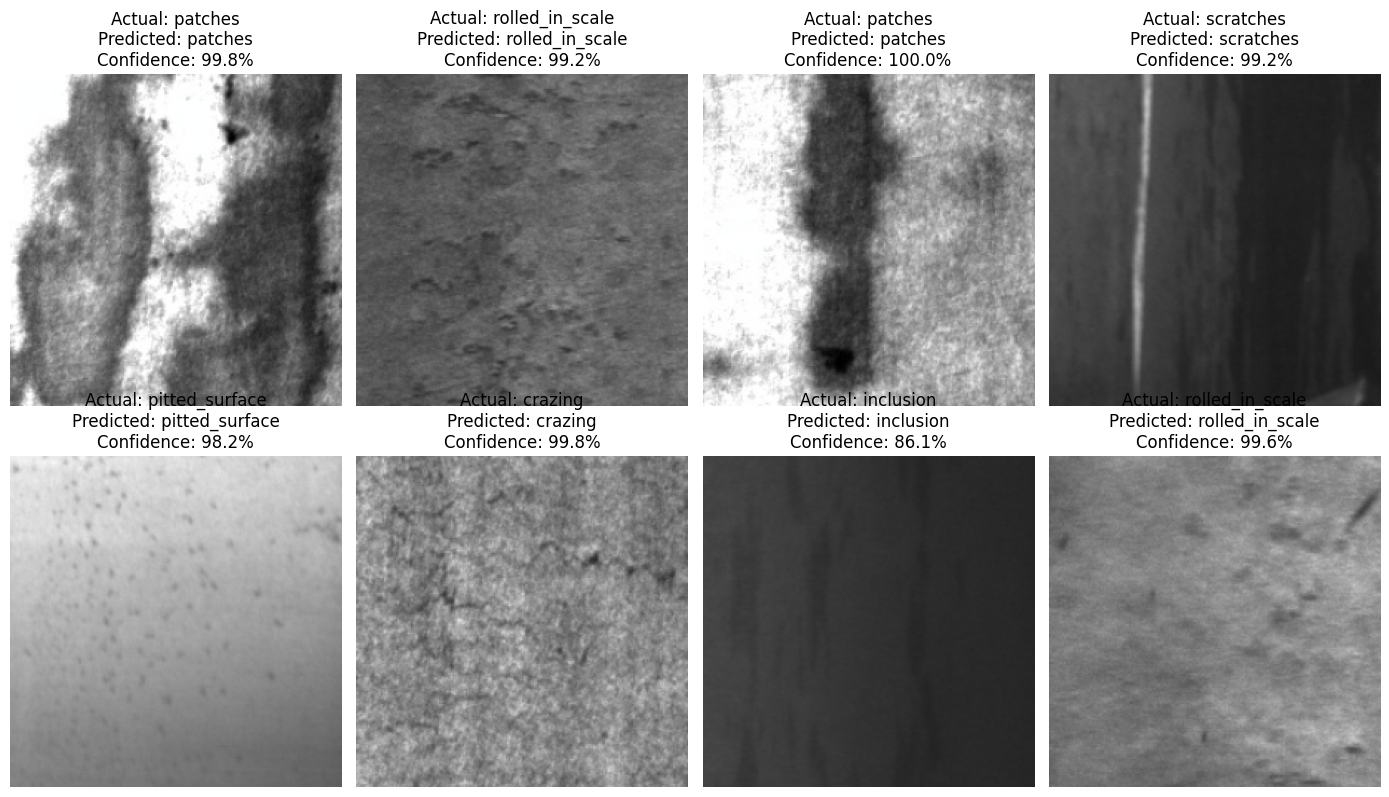

Qualitative results saved to:
/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/results/mobilenetv2/finetuned_qualitative_results.png


In [99]:
show_predictions(
    finetuned_model,
    test_dataset,
    CLASS_NAMES,
    number_of_images=8,
    save_name="finetuned_qualitative_results.png"
)

Fine-Tuned Failure Cases

In [100]:
finetuned_incorrect_indices = np.where(
    finetuned_true_labels != finetuned_predicted_labels
)[0]

print(
    "Number of incorrect predictions:",
    len(finetuned_incorrect_indices)
)

print(
    "Number of correct predictions:",
    len(finetuned_true_labels)
    - len(finetuned_incorrect_indices)
)

Number of incorrect predictions: 0
Number of correct predictions: 270


Save Fine-Tuned Predictions

In [101]:
finetuned_predictions_df = pd.DataFrame({
    "True Label": [
        CLASS_NAMES[label]
        for label in finetuned_true_labels
    ],
    "Predicted Label": [
        CLASS_NAMES[label]
        for label in finetuned_predicted_labels
    ],
    "Confidence": finetuned_confidence_scores
})

finetuned_predictions_path = (
    RESULTS_DIR / "finetuned_test_predictions.csv"
)

finetuned_predictions_df.to_csv(
    finetuned_predictions_path,
    index=False
)

display(
    finetuned_predictions_df.head()
)

print("Fine-tuned predictions saved to:")
print(finetuned_predictions_path)

,True Label,Predicted Label,Confidence
0,crazing,crazing,0.989442
1,crazing,crazing,0.977588
2,crazing,crazing,0.991758
3,crazing,crazing,0.998009
4,crazing,crazing,0.981329


Fine-tuned predictions saved to:
/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/results/mobilenetv2/finetuned_test_predictions.csv


Frozen vs Fine-Tuned Comparison

In [102]:
mobilenet_comparison_df = pd.DataFrame({
    "Model": [
        "MobileNetV2 Frozen",
        "MobileNetV2 Fine-Tuned"
    ],
    "Accuracy": [
        test_accuracy,
        finetuned_test_accuracy
    ],
    "Macro Precision": [
        test_precision,
        finetuned_test_precision
    ],
    "Macro Recall": [
        test_recall,
        finetuned_test_recall
    ],
    "Macro F1-Score": [
        test_f1,
        finetuned_test_f1
    ]
})

comparison_path = (
    RESULTS_DIR / "mobilenetv2_comparison.csv"
)

mobilenet_comparison_df.to_csv(
    comparison_path,
    index=False
)

display(mobilenet_comparison_df)

print("MobileNetV2 comparison saved to:")
print(comparison_path)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
0,MobileNetV2 Frozen,0.996296,0.996377,0.996296,0.996296
1,MobileNetV2 Fine-Tuned,1.000000,1.000000,1.000000,1.000000


MobileNetV2 comparison saved to:
/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection/results/mobilenetv2/mobilenetv2_comparison.csv


# Final Observation

The frozen MobileNetV2 model achieved 99.63% test accuracy, correctly classifying 269 out of 270 test images.

After fine-tuning the final three MobileNetV2 feature blocks using a lower learning rate, the model achieved 100.00% test accuracy, correctly classifying all 270 test images.

Fine-tuning therefore corrected the remaining classification error observed in the frozen model.

The final fine-tuned model achieved:

- Test Accuracy: 100.00%
- Macro Precision: 100.00%
- Macro Recall: 100.00%
- Macro F1-Score: 100.00%

No failure cases were observed on the final test set.